## [Simulate Stock Prices with Python](https://medium.com/coding-nexus/how-to-simulate-stock-prices-with-python-66b64a4d4ce5)

Stock price simulation is a building block of quantitative finance.

**Geometric Brownian Motion** is a process where the logarithm of a stock price follows a random walk. The randomness comes from what's called a Wiener process, also known as Brownian motion.

Brownian motion actually refers to the erratic, seemingly random, and zig-zag movement of microscopic particles suspended in a fluid. This happens since the particles are constantly bombarded by the much smaller, rapidly moving molecules of the fluid.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

s0 = 131.00       # starting stock price
sigma = 0.25      # annual volatility (25%)
mu = 0.35         # annual return (35%)
paths = 1000      # number of simulated price paths
dt = 1.0 / 252.0  # time step (1 trading day)
time = 252 * 5    # total days (5 years)

In [2]:
def wiener_process(dt, sigma, time, paths):
    # Generate Wiener process for GBM.
    return sigma * np.random.normal(loc=0, scale=np.sqrt(dt), size=(time, paths))

In [3]:
def gbm_returns(dt, sigma, time, mu, paths):
    """Create GBM returns using drift and Wiener process."""
    process = wiener_process(dt, sigma, time, paths)
    return np.exp(process + (mu - 0.5 * sigma ** 2) * dt)

In [4]:
def gbm_levels(s0, dt, sigma, time, mu, paths):
    """Generate stock price paths using GBM."""
    returns = gbm_returns(dt, sigma, time, mu, paths)
    stacked = np.vstack([np.ones(paths), returns])
    return s0 * stacked.cumprod(axis=0)

In [5]:
price_paths = gbm_levels(s0, dt, sigma, time, mu, paths)

In [6]:
price_paths

array([[ 131.        ,  131.        ,  131.        , ...,  131.        ,
         131.        ,  131.        ],
       [ 131.7777928 ,  132.51194616,  134.71159882, ...,  134.35780529,
         131.90097764,  133.47942885],
       [ 134.21135032,  132.05300179,  137.56665783, ...,  136.29814396,
         130.0633746 ,  134.54133943],
       ...,
       [ 719.14248225,  887.11225604,  495.39793719, ...,  456.25659435,
        2025.16689447,  401.9329025 ],
       [ 705.40326816,  880.69676306,  495.02746502, ...,  464.95231453,
        2034.03947386,  395.7891781 ],
       [ 713.91594809,  872.07794113,  498.86479184, ...,  472.91538605,
        2042.86324257,  397.18900986]])

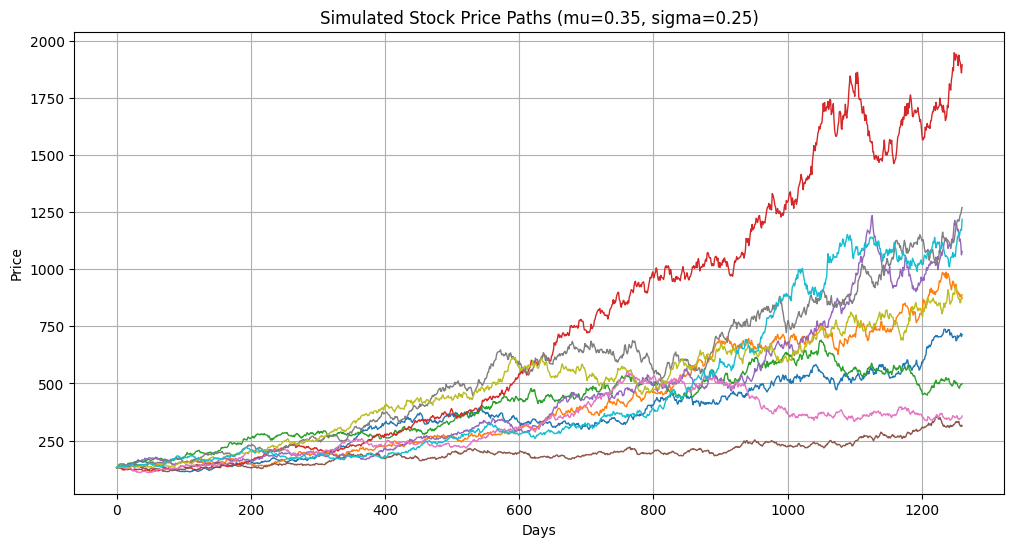

In [7]:
plt.figure(figsize=(12, 6))
for i in range(10):
    plt.plot(price_paths[:, i], linewidth=1)
plt.title("Simulated Stock Price Paths (mu=0.35, sigma=0.25)")
plt.xlabel("Days")
plt.ylabel("Price")
plt.grid(True)
plt.show()

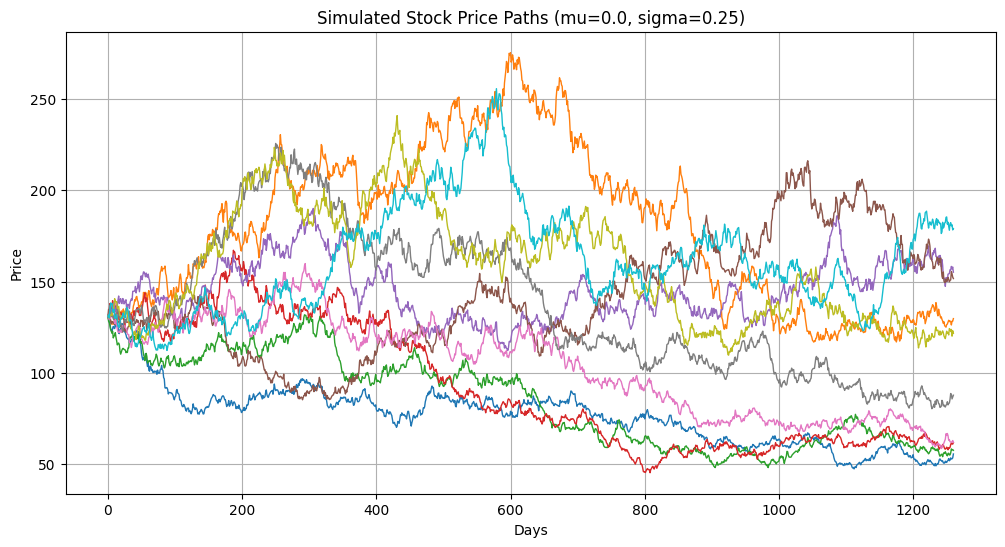

In [8]:
price_paths = gbm_levels(s0, dt, sigma, time, 0.0, paths)

plt.figure(figsize=(12, 6))
for i in range(10):
    plt.plot(price_paths[:, i], linewidth=1)
plt.title("Simulated Stock Price Paths (mu=0.0, sigma=0.25)")
plt.xlabel("Days")
plt.ylabel("Price")
plt.grid(True)
plt.show()

In [9]:
np.sum(price_paths[-1, :] > s0)

np.int64(380)